# Домашнее задание 2. Выпуклость

**Выдано:** 23 сентября 2026. **Срок сдачи:** 7 октября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw02/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 2 ([конспект](../lectures/lecture02/lecture02.md), [демо](../lectures/lecture02/demo02.ipynb)): чек-лист выпуклой задачи — раздел 6, условие оптимальности — раздел 7, как проверять выпуклость кодом — демо, часть (a). Ничего сверх лекции не требуется. Ориентировочное время — 3–4 часа.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

rng = np.random.default_rng(2026)

## Задача 1. Выпуклость (4 балла)

По 1 баллу за пункт. В каждом пункте нужен либо аргумент «почему выпукло» — определение, критерий первого/второго порядка или операция из раздела 5 конспекта, — либо контрпример: две точки и вылезающий наружу отрезок, хорда под графиком или точка, где гессиан не полуопределён. Численная проверка приветствуется, но доказательством не считается (демо, часть a).

**(а) Множества.** Выпуклы ли:

1. $\{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$;
2. $\{x \in \mathbb{R}^n : \Vert Ax - b\Vert_2 \le 1\}$ при произвольных $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$;
3. $\{x \in \mathbb{R}^2 : \Vert x\Vert_2 \ge 1\}$?

**(б) Критерий второго порядка.**

1. При каких $a \in \mathbb{R}$ функция $f(x) = x_1^2 + a\,x_1 x_2 + x_2^2$ выпукла на $\mathbb{R}^2$? При каких — строго выпукла? Проверьте ответ через `np.linalg.eigvalsh` для нескольких значений $a$.
2. Выпукла ли $g(x) = x_1^2 x_2^2$ на $\mathbb{R}^2$?

**(в) Операции.** Докажите выпуклость или объясните, почему правила раздела 5 не применимы, и приведите контрпример:

1. $f(x) = \Vert Ax - b\Vert_2 + \lambda\,\Vert x\Vert_\infty$, $\lambda \ge 0$;
2. $f(x) = \max_{i} \big(a_i^\top x - b_i\big)^2$;
3. $f(x) = e^{-\Vert x\Vert_2^2}$.

Какие из трёх функций гладкие?

**(г) Задачи ДЗ 1.** Вернитесь к задаче 1 домашнего задания 1 — пункты (а)–(г) и бонус (д). Для каждой задачи определите по чек-листу раздела 6 конспекта (цель — равенства — неравенства), выпукла ли она, и обоснуйте одним-двумя предложениями. Для невыпуклых укажите, что именно ломает выпуклость.

**(а)**

**Ответ:**

1. **Множество выпукло:** это надграфик выпуклой функции $s\mapsto s^2$. Действительно, для допустимых $x,y$ и $\theta\in[0,1]$ точка $z=(1-\theta)x+\theta y$ удовлетворяет

   $$
   z_2=(1-\theta)x_2+\theta y_2
   \ge(1-\theta)x_1^2+\theta y_1^2
   \ge\big((1-\theta)x_1+\theta y_1\big)^2=z_1^2.
   $$

2. **Множество выпукло** при любых $A,b$: это аффинный прообраз единичного евклидова шара. Для любых допустимых $x,y$ по неравенству треугольника

   $$
   \|A((1-\theta)x+\theta y)-b\|_2
   =\|(1-\theta)(Ax-b)+\theta(Ay-b)\|_2
   \le(1-\theta)\|Ax-b\|_2+\theta\|Ay-b\|_2\le1.
   $$

   Полный ранг $A$ не требуется; если допустимых точек нет, пустое множество также выпукло.

3. **Множество невыпукло.** Точки $x=(1,0)^\top$ и $y=(-1,0)^\top$ ему принадлежат, но их середина $(x+y)/2=(0,0)^\top$ имеет норму $0<1$ и не принадлежит множеству.

**(б)**

**Ответ:**

1. Для $f(x)=x_1^2+a x_1x_2+x_2^2$ гессиан постоянен:

   $$
   \nabla^2f=\begin{pmatrix}2&a\\a&2\end{pmatrix},
   \qquad \lambda_1=2+a,\quad\lambda_2=2-a.
   $$

   Поэтому $f$ **выпукла тогда и только тогда, когда $|a|\le2$**, и **строго выпукла тогда и только тогда, когда $|a|<2$**. При $a=2$ имеем $f=(x_1+x_2)^2$, а при $a=-2$ — $f=(x_1-x_2)^2$: на прямых $x_1=-x_2$ и $x_1=x_2$ соответственно функция постоянна, поэтому строгой выпуклости нет. При $|a|>2$ гессиан имеет отрицательное собственное значение, что исключает выпуклость.

2. Для $g(x)=x_1^2x_2^2$

   $$
   \nabla^2g(x)=
   \begin{pmatrix}
   2x_2^2&4x_1x_2\\
   4x_1x_2&2x_1^2
   \end{pmatrix}.
   $$

   В точке $(1,1)^\top$ собственные значения равны $6$ и $-2$, поэтому $g$ **невыпукла** на $\mathbb R^2$. Это также видно по хорде: $g(1,0)=g(0,1)=0$, но $g(1/2,1/2)=1/16>0$.

Численная проверка ниже иллюстрирует полученные аналитически условия.

In [2]:
eigenvalue_tolerance = 1e-12
print(f"{'a':>5} {'Собственные значения':>24} {'Выпукла':>10} {'Строго выпукла':>17}")
for parameter in [-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0]:
    hessian = np.array([[2.0, parameter], [parameter, 2.0]])
    eigenvalues = np.linalg.eigvalsh(hessian)
    convex = eigenvalues.min() >= -eigenvalue_tolerance
    strictly_convex = eigenvalues.min() > eigenvalue_tolerance
    print(f"{parameter:5.1f} {str(eigenvalues):>24} {str(convex):>10} {str(strictly_convex):>17}")

hessian_g = np.array([[2.0, 4.0], [4.0, 2.0]])
print("Собственные значения гессиана g в точке (1, 1):", np.linalg.eigvalsh(hessian_g))

    a     Собственные значения    Выпукла    Строго выпукла
 -3.0                [-1.  5.]      False             False
 -2.0                  [0. 4.]       True             False
 -1.0                  [1. 3.]       True              True
  0.0                  [2. 2.]       True              True
  1.0                  [1. 3.]       True              True
  2.0                  [0. 4.]       True             False
  3.0                [-1.  5.]      False             False
Собственные значения гессиана g в точке (1, 1): [-2.  6.]


**(в)**

**Ответ:**

1. $\|Ax-b\|_2+\lambda\|x\|_\infty$ **выпукла** при $\lambda\ge0$: любая норма выпукла, композиция с аффинным отображением сохраняет выпуклость, как и неотрицательная взвешенная сумма. **В общем случае функция негладкая**: уже при $n=m=1$, $A=1$, $b=0$, $\lambda=0$ получаем $|x|$, не дифференцируемую в нуле; норма $\|x\|_\infty$ также может создавать изломы.

2. Каждый квадрат $(a_i^\top x-b_i)^2$ — выпуклая функция как композиция квадрата с аффинным отображением; его гессиан равен $2a_i a_i^\top\succeq0$. Поточечный максимум этих функций **выпуклый**, но **в общем случае негладкий**: например,

   $$
   \max\{(x-1)^2,(x+1)^2\}=x^2+2|x|+1
   $$

   имеет разные односторонние производные в нуле. Если максимум достигается сразу на нескольких функциях, негладкость возникает при несовпадении их градиентов; само совпадение значений ещё не означает излом.

3. $e^{-\|x\|_2^2}$ **не выпукла**: правило композиции с выпуклой неубывающей экспонентой не применимо, поскольку внутренняя функция $-\|x\|_2^2$ вогнута. Например, для единичного вектора $e_1$

   $$
   f(0)=1>e^{-1}=\frac{f(e_1)+f(-e_1)}2,
   $$

   что нарушает неравенство выпуклости. При этом функция **гладкая класса $C^\infty$** на $\mathbb R^n$; её гессиан $e^{-\|x\|^2}(4xx^\top-2I)$ в нуле равен $-2I$.

Итак, третья функция гладкая всегда; для первых двух гладкость без дополнительных условий не гарантируется (в отдельных частных случаях они могут быть гладкими).

**(г)**

**Ответ:** Используем соглашение $g(x)=0$, $h(x)\ge0$ и постановки из ДЗ 1.

- **(а) Ближайшая точка прямой — выпуклая QP.** Цель $\|x-(1,2,3)^\top\|_2^2$ имеет гессиан $2I\succ0$, равенства $x_1+x_2+x_3=1$ и $x_1-x_3=0$ аффинны, неравенств нет.
- **(б) Диета — выпуклая LP.** Цель $c^\top x$ аффинна, равенств нет, а все компоненты $h(x)=(Ax-b,x)^\top$ аффинны и потому вогнуты.
- **(в) Прямоугольник — невыпуклая QCQP в постановке через полустороны $u,v$.** Цель $-4uv$ имеет гессиан с собственными значениями $\pm4$, равенство $u^2+v^2=1$ задаёт невыпуклую дугу, тогда как неравенства $u,v\ge0$ аффинны; если заменить равенство на вогнутое неравенство $1-u^2-v^2\ge0$, допустимое множество станет выпуклым, но цель останется невыпуклой и внутри него.
- **(г) Синус с неизвестными амплитудой, частотой и фазой — невыпуклая NLP без ограничений.** Выпуклость нарушает цель: при $x_1=1$, $x_2=0$ она становится непостоянной периодической функцией $x_3$, которая не может быть выпуклой на всей прямой.
- **(д) Чебышёвская подгонка — выпуклая задача.** В исходной записи цель $\max_i|a_i^\top x-b_i|$ выпукла как максимум модулей аффинных функций и ограничений нет; после введения $\tau$ цель $\tau$ и неравенства $\tau\pm(a_i^\top x-b_i)\ge0$ аффинны, равенств нет, поэтому получается выпуклая LP.

## Задача 2. Практика (6 баллов)

**(а) Проекция на полупространство (3 балла).** Пусть $\Omega = \{x \in \mathbb{R}^n : a^\top x \le b\}$, $a \ne 0$, и точка $p$ лежит вне $\Omega$, то есть $a^\top p > b$. Задача проекции — $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$ (раздел 7 конспекта, пример 2).

1. Из условия оптимальности $\nabla f(x^\ast)^\top(y - x^\ast) \ge 0\ \ \forall y \in \Omega$ выведите явную формулу

$$x^\ast = p - \frac{a^\top p - b}{\Vert a\Vert^2}\, a .$$

Подсказки: (i) почему $x^\ast$ не может лежать строго внутри $\Omega$; (ii) для любого $v$ с $a^\top v = 0$ точки $y = x^\ast \pm v$ допустимы — что даёт условие для них; (iii) коэффициент при $a$ найдите из $a^\top x^\ast = b$; (iv) убедитесь, что при таком коэффициенте условие выполнено и для всех остальных $y \in \Omega$ — тогда, по теореме раздела 7, $x^\ast$ действительно решение.

2. Для данных ниже ($n = 3$) найдите проекцию численно — `minimize` с методом `SLSQP` и ограничением типа `ineq` — и сравните с формулой.

3. Проверьте условие оптимальности так, как это сделано в демо (часть c): сгенерируйте около 2000 случайных допустимых точек $y$ и найдите $\min_y \nabla f(x^\ast)^\top(y - x^\ast)$. Повторите для заведомо неоптимальной допустимой точки, например $x = 0$. Что означает знак результата в каждом случае?

In [3]:
a = np.array([1.0, 2.0, -1.0])
b = 1.0
p = np.array([3.0, 1.0, 0.5])
assert a @ p > b

**Вывод формулы (пункт 1)**

**Ответ:** Полупространство $\Omega$ непусто, замкнуто и выпукло, а $f(x)=\tfrac12\|x-p\|^2$ строго выпукла и коэрцитивна. Поэтому проекция существует и единственна; для неё необходимо и достаточно

$$
(x^*-p)^\top(y-x^*)\ge0\qquad\forall y\in\Omega.
$$

Если бы $a^\top x^*<b$, то при достаточно малом $\varepsilon>0$ точка $y=x^*+\varepsilon(p-x^*)$ оставалась бы допустимой. Однако

$$
(x^*-p)^\top(y-x^*)=-\varepsilon\|x^*-p\|^2<0,
$$

поскольку $p\notin\Omega$; получаем противоречие. Значит, $a^\top x^*=b$.

Для любого $v$ с $a^\top v=0$ обе точки $x^*+v$ и $x^*-v$ допустимы. Подставляя их в условие оптимальности, получаем одновременно $(x^*-p)^\top v\ge0$ и $-(x^*-p)^\top v\ge0$, следовательно $(x^*-p)^\top v=0$. Поэтому $x^*-p$ параллелен $a$, то есть $x^*-p=-\mu a$. Из граничного равенства

$$
a^\top p-\mu\|a\|^2=b
\quad\Longrightarrow\quad
\mu=\frac{a^\top p-b}{\|a\|^2}>0.
$$

Таким образом,

$$
\boxed{x^*=p-\frac{a^\top p-b}{\|a\|^2}\,a}.
$$

Для любого $y\in\Omega$ найденная точка удовлетворяет

$$
(x^*-p)^\top(y-x^*)
=-\mu(a^\top y-b)=\mu(b-a^\top y)\ge0.
$$

По достаточности условия оптимальности это действительно единственное решение. Если $p\in\Omega$, проекция равна $p$; общая формула имеет вид $P_\Omega(p)=p-\max(0,a^\top p-b)a/\|a\|^2$.

**Численная проверка (пункты 2 и 3)**

In [4]:
normal_squared = a @ a
x_formula = p - (a @ p - b) / normal_squared * a

def projection_objective(x):
    return 0.5 * np.sum((x - p) ** 2)

def projection_gradient(x):
    return x - p

projection_result = minimize(
    projection_objective,
    x0=np.zeros(p.size),
    jac=projection_gradient,
    method="SLSQP",
    constraints=[{"type": "ineq", "fun": lambda x: b - a @ x, "jac": lambda x: -a}],
    options={"ftol": 1e-12, "maxiter": 1000},
)
if not projection_result.success:
    raise RuntimeError(projection_result.message)

print("Проекция по формуле:", x_formula)
print("Проекция SLSQP:", projection_result.x)
print(f"Расстояние между решениями: {np.linalg.norm(projection_result.x - x_formula):.3e}")
print(f"Значение цели: {projection_result.fun:.12f}")
print(f"Невязка b - aᵀx для SLSQP: {b - a @ projection_result.x:.3e}")

feasible_points = 3.0 * rng.standard_normal((2000, p.size))
violations = np.maximum(feasible_points @ a - b, 0.0)
feasible_points -= violations[:, None] * a / normal_squared
optimality_tolerance = 1e-10
assert np.all(feasible_points @ a <= b + optimality_tolerance)

for label, candidate in [
    ("Формула", x_formula),
    ("SLSQP", projection_result.x),
    ("Нулевая точка", np.zeros(p.size)),
]:
    values = (feasible_points - candidate) @ projection_gradient(candidate)
    print(f"{label}: min ⟨∇f(x), y - x⟩ = {values.min():.12g}")
    print("Нарушений на выборке:", np.count_nonzero(values < -optimality_tolerance))

zero_values = feasible_points @ projection_gradient(np.zeros(p.size))
witness = feasible_points[np.argmin(zero_values)]
print("Точка y, нарушающая условие для x = 0:", witness)
print(f"Её невязка b - aᵀy: {b - a @ witness:.6f}")

Проекция по формуле: [ 2.41666667 -0.16666667  1.08333333]
Проекция SLSQP: [ 2.41666667 -0.16666667  1.08333333]
Расстояние между решениями: 0.000e+00
Значение цели: 1.020833333333
Невязка b - aᵀx для SLSQP: 4.441e-16
Формула: min ⟨∇f(x), y - x⟩ = -2.6645352591e-15
Нарушений на выборке: 0
SLSQP: min ⟨∇f(x), y - x⟩ = -2.6645352591e-15
Нарушений на выборке: 0
Нулевая точка: min ⟨∇f(x), y - x⟩ = -29.6713080737
Нарушений на выборке: 822
Точка y, нарушающая условие для x = 0: [7.95250837 1.10421884 9.41912826]
Её невязка b - aᵀy: 0.258182


**Ответ:** Для данных задачи $a^\top p=4.5$, $\|a\|^2=6$, поэтому

$$
x^*=p-\frac7{12}a
=\left(\frac{29}{12},-\frac16,\frac{13}{12}\right)^\top,
\qquad a^\top x^*=1,\qquad f(x^*)=\frac{49}{48}\approx1.02083333.
$$

SLSQP успешно находит то же решение с точностью округления. Для проверки сгенерированы 2000 случайных точек: точки за границей полупространства перенесены на его границу по нормали, поэтому все проверяемые точки допустимы с учётом вычислительной погрешности.

В $x^*$ минимум скалярного произведения по выборке практически нулевой (порядка $-10^{-15}$, то есть неотрицательный с допуском $10^{-10}$): допустимых направлений убывания на выборке не найдено. Это согласуется с доказанным условием оптимальности, но сама конечная случайная проверка доказательством не является.

В допустимой точке $x=0$ минимум составляет примерно $-29.67$: найдено направление $y-x$, вдоль которого цель убывает при достаточно малом положительном шаге, так что $0$ не оптимальна. Это можно подтвердить и без случайных точек: $y=0.1p\in\Omega$, поскольку $a^\top y=0.45\le1$, а $\nabla f(0)^\top y=-0.1\|p\|^2=-1.025<0$.

**(б) Выпуклая и невыпуклая подгонка (3 балла).** Ниже сгенерированы измерения $y_i = 2\sin(3t_i + 0.7) + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0, 0.2^2)$, $i = 1, \dots, 60$. Один и тот же сигнал описываем двумя моделями:

- **A** (задача 1(г) ДЗ 1): $\varphi_A(t; x) = x_1 \sin(x_2 t + x_3)$, $x \in \mathbb{R}^3$ — амплитуда, частота и фаза неизвестны;
- **B** (частота известна, $\omega = 3$): $\varphi_B(t; x) = x_1 \sin\omega t + x_2 \cos\omega t$, $x \in \mathbb{R}^2$.

Цель в обоих случаях — сумма квадратов невязок $f(x) = \tfrac12\sum_i \big(\varphi(t_i; x) - y_i\big)^2$.

1. Какого класса каждая задача и выпукла ли она? Для B — докажите; для A — объясните, почему нет (подсказка: что происходит с $f$ при $x_3 \to x_3 + 2\pi$ и при $(x_1, x_3) \to (-x_1, x_3 + \pi)$?).
2. Запустите `minimize(..., method="BFGS")` для обеих моделей из 20 одинаковых случайных стартов `starts` (для B берите первые две координаты старта). Выведите итоговые значения $f$ по стартам и долю стартов, пришедших к наименьшему найденному значению; нарисуйте данные и подогнанные кривые для обеих моделей.
3. Объясните результат через главную теорему лекции. Как из решения B получить амплитуду и фазу для модели A? Почему наименьшее найденное $f$ у A чуть меньше, чем у B, и почему это не делает A «лучшей» задачей?

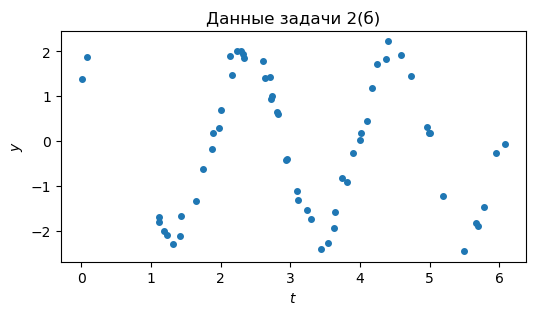

In [5]:
data_rng = np.random.default_rng(2026)
N, omega = 60, 3.0
t = np.sort(data_rng.uniform(0, 2 * np.pi, N))
y = 2.0 * np.sin(3.0 * t + 0.7) + 0.2 * data_rng.standard_normal(N)
starts = data_rng.uniform(-5, 5, (20, 3))

plt.figure(figsize=(6, 3))
plt.plot(t, y, "o", ms=4)
plt.xlabel("$t$")
plt.ylabel("$y$")
plt.title("Данные задачи 2(б)")
plt.show()

**Класс и выпуклость (пункт 1)**

**Ответ:** **Модель A — гладкая невыпуклая NLP без ограничений**, задача нелинейных наименьших квадратов по трём параметрам:

$$
f_A(x)=\frac12\sum_{i=1}^N\big(x_1\sin(x_2t_i+x_3)-y_i\big)^2.
$$

Она обладает симметриями

$$
f_A(x_1,x_2,x_3+2\pi)=f_A(x_1,x_2,x_3),\qquad
f_A(-x_1,x_2,x_3+\pi)=f_A(x_1,x_2,x_3),
$$

то есть разные параметры могут задавать одну и ту же кривую. Само наличие нескольких одинаковых значений ещё не доказывает невыпуклость, но здесь можно предъявить конкретное нарушение критерия второго порядка: на прямой $x_1=1$, $x_2=0$

$$
F(s)=f_A(1,0,s)=\frac12\sum_i(\sin s-y_i)^2,
\qquad F''(s)=N\cos(2s)+\left(\sum_i y_i\right)\sin s.
$$

При $s=\pi/2$ и $s=-\pi/2$ вторые производные равны $-N+\sum_i y_i$ и $-N-\sum_i y_i$ соответственно; хотя бы одна из них отрицательна, поскольку их сумма $-2N<0$. Следовательно, ограничение функции на прямую невыпукло, а значит невыпукла и $f_A$.

**Модель B — выпуклая QP без ограничений**, линейный МНК по двум коэффициентам. Обозначим

$$
D_{i1}=\sin(\omega t_i),\qquad D_{i2}=\cos(\omega t_i).
$$

Тогда

$$
f_B(x)=\frac12\|Dx-y\|^2,\qquad
\nabla f_B(x)=D^\top(Dx-y),\qquad
\nabla^2 f_B=D^\top D\succeq0,
$$

так как $v^\top D^\top Dv=\|Dv\|^2\ge0$ для любого $v$. Для данных задачи столбцы $D$ линейно независимы: если $t_i=\min_j t_j$ и $t_k$ — ближайшее к нему большее значение, то $0<\omega(t_k-t_i)<\pi$, а определитель соответствующих двух строк равен $\sin(\omega(t_i-t_k))\ne0$. Поэтому здесь гессиан положительно определён, функция строго выпукла и решение единственно; численно его собственные значения примерно $28.16194$ и $31.83806$.

**Мультистарт (пункт 2)**

Старт             f_A  success A    ||∇f_A||∞             f_B  success B
    1    1.1392730978       True    6.561e-08    1.1407640089       True
    2   63.8248905646      False    7.499e-02    1.1407640089       True
    3    1.1392730978       True    7.043e-09    1.1407640089       True
    4    1.1392730978       True    3.430e-06    1.1407640089       True
    5    1.1392730978       True    3.948e-06    1.1407640089       True
    6   61.4972734409       True    1.262e-06    1.1407640089       True
    7   61.4972734409       True    8.777e-08    1.1407640089       True
    8   64.2517755579       True    9.502e-07    1.1407640089       True
    9    1.1392730978       True    6.809e-09    1.1407640089       True
   10   63.8248905670      False    1.141e-01    1.1407640089       True
   11    1.1392730978       True    1.508e-06    1.1407640089       True
   12    1.1392730978       True    2.531e-07    1.1407640089       True
   13   61.4972734409       True    2.638e-07    1.

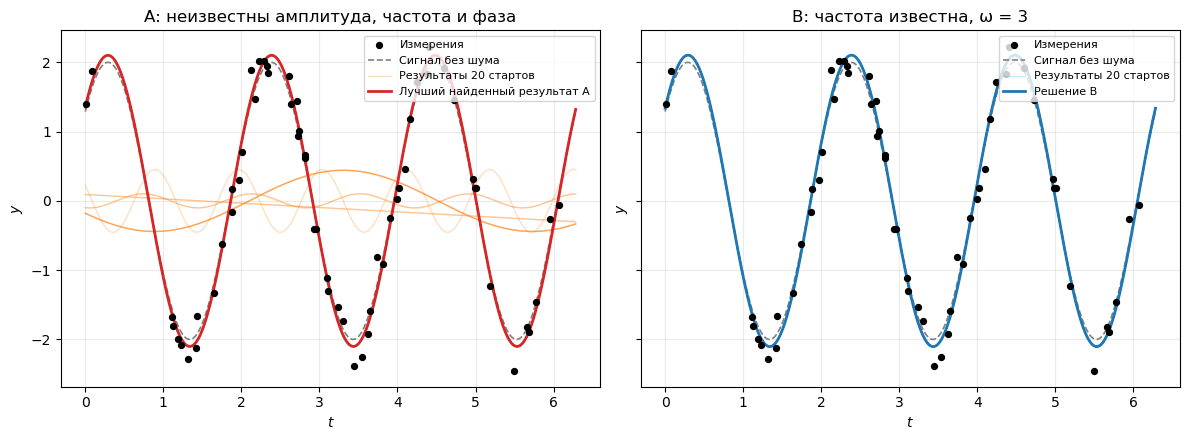

In [6]:
design = np.column_stack((np.sin(omega * t), np.cos(omega * t)))

def model_a(times, parameters):
    return parameters[0] * np.sin(parameters[1] * times + parameters[2])

def objective_a(parameters):
    residual = model_a(t, parameters) - y
    return 0.5 * residual @ residual

def gradient_a(parameters):
    phase = parameters[1] * t + parameters[2]
    residual = parameters[0] * np.sin(phase) - y
    scaled_cosine = parameters[0] * np.cos(phase)
    return np.array([
        residual @ np.sin(phase),
        residual @ (t * scaled_cosine),
        residual @ scaled_cosine,
    ])

def objective_b(parameters):
    residual = design @ parameters - y
    return 0.5 * residual @ residual

def gradient_b(parameters):
    return design.T @ (design @ parameters - y)

bfgs_options = {"gtol": 1e-5, "maxiter": 1000}
results_a = [
    minimize(objective_a, start, jac=gradient_a, method="BFGS", options=bfgs_options)
    for start in starts
]
results_b = [
    minimize(objective_b, start[:2], jac=gradient_b, method="BFGS", options=bfgs_options)
    for start in starts
]

print(f"{'Старт':>5} {'f_A':>15} {'success A':>10} {'||∇f_A||∞':>12} {'f_B':>15} {'success B':>10}")
for index, (result_a, result_b) in enumerate(zip(results_a, results_b), start=1):
    gradient_norm = np.linalg.norm(gradient_a(result_a.x), ord=np.inf)
    print(f"{index:5d} {result_a.fun:15.10f} {str(result_a.success):>10} "
          f"{gradient_norm:12.3e} {result_b.fun:15.10f} {str(result_b.success):>10}")

value_tolerance = 1e-6
for label, results in [("A", results_a), ("B", results_b)]:
    final_values = np.array([result.fun for result in results])
    best_value = final_values.min()
    reached_best = np.isclose(final_values, best_value, atol=value_tolerance, rtol=0.0)
    successful = np.array([result.success for result in results])
    print(f"\nМодель {label}: наименьшее найденное f = {best_value:.10f}")
    print(f"Доля стартов с |f - f_min| ≤ {value_tolerance:g}: "
          f"{reached_best.sum()}/{len(results)} = {reached_best.mean():.0%}")
    print(f"Из них со статусом success=True: {(reached_best & successful).sum()}")
    for index, result in enumerate(results, start=1):
        if not result.success:
            print(f"Старт {index}: {result.message}")

best_a = min(results_a, key=lambda result: result.fun)
best_b = min(results_b, key=lambda result: result.fun)
reference_b = np.linalg.lstsq(design, y, rcond=None)[0]
maximum_b_error = max(np.linalg.norm(result.x - reference_b) for result in results_b)
print("\nСобственные значения DᵀD:", np.linalg.eigvalsh(design.T @ design))
print(f"ω(t₂ - t₁) = {omega * (t[1] - t[0]):.8f}")
print("Решение B через lstsq:", reference_b)
print(f"Наибольшее отклонение BFGS от lstsq по 20 стартам: {maximum_b_error:.3e}")

amplitude_b = np.linalg.norm(best_b.x)
phase_b = np.arctan2(best_b.x[1], best_b.x[0])
amplitude_a, frequency_a, phase_a = best_a.x.copy()
if frequency_a < 0:
    amplitude_a, frequency_a, phase_a = -amplitude_a, -frequency_a, -phase_a
if amplitude_a < 0:
    amplitude_a, phase_a = -amplitude_a, phase_a + np.pi
phase_a = (phase_a + np.pi) % (2 * np.pi) - np.pi
print(f"A: амплитуда = {amplitude_a:.8f}, частота = {frequency_a:.8f}, фаза = {phase_a:.8f}")
print(f"B: амплитуда = {amplitude_b:.8f}, частота = {omega:.8f}, фаза = {phase_b:.8f}")
print(f"Разность наименьших значений f_B - f_A: {best_b.fun - best_a.fun:.10f}")

time_grid = np.linspace(0.0, 2 * np.pi, 1200)
design_grid = np.column_stack((np.sin(omega * time_grid), np.cos(omega * time_grid)))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for axis in axes:
    axis.scatter(t, y, color="black", s=18, zorder=4, label="Измерения")
    axis.plot(time_grid, 2 * np.sin(3 * time_grid + 0.7), "--", color="gray",
              linewidth=1.2, label="Сигнал без шума")
    axis.set_xlabel("$t$")
    axis.set_ylabel("$y$")
    axis.grid(alpha=0.25)

for index, result in enumerate(results_a):
    axes[0].plot(time_grid, model_a(time_grid, result.x), color="tab:orange", alpha=0.25,
                 linewidth=1, label="Результаты 20 стартов" if index == 0 else None)
axes[0].plot(time_grid, model_a(time_grid, best_a.x), color="tab:red", linewidth=2,
             label="Лучший найденный результат A")
axes[0].set_title("A: неизвестны амплитуда, частота и фаза")

for index, result in enumerate(results_b):
    axes[1].plot(time_grid, design_grid @ result.x, color="tab:cyan", alpha=0.25,
                 linewidth=1, label="Результаты 20 стартов" if index == 0 else None)
axes[1].plot(time_grid, design_grid @ best_b.x, color="tab:blue", linewidth=2,
             label="Решение B")
axes[1].set_title("B: частота известна, ω = 3")
for axis in axes:
    axis.legend(fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()

**Объяснение (пункт 3)**

**Ответ:** Долю считаем среди всех 20 запусков по условию $|f-f_{\min}|\le10^{-6}$ с нулевым относительным допуском; статусы `success` выведены отдельно. Для **A** наименьшее найденное значение $f_A\approx1.13927310$ достигается в **11 из 20 запусков (55%)**; для **B** все **20 из 20 (100%)** дают $f_B\approx1.14076401$ и совпадают с решением `lstsq` в пределах численной точности.

По главной теореме лекции любой локальный минимум выпуклой задачи глобален, а строгая выпуклость B дополнительно обеспечивает единственность решения: поэтому успешно сошедшиеся запуски дают одну точку. Сама теорема не утверждает сходимость произвольного численного метода из любого старта; в этом эксперименте сходимость BFGS подтверждается его статусами и сравнением с линейным МНК.

Для A такой гарантии глобальности нет: часть запусков заканчивается при существенно больших значениях цели (около $61.50$, $61.69$ и $64.25$), а старты 2 и 10 исчерпывают лимит 1000 итераций при $f\approx63.82$ и не считаются подтверждёнными локальными минимумами. Параметры A также могут различаться из-за симметрий синуса, даже если кривые совпадают; 20 стартов не доказывают глобальность лучшего найденного значения.

Если решение B равно $(\alpha,\beta)^\top$, то по формуле сложения

$$
\alpha\sin(\omega t)+\beta\cos(\omega t)
=R\sin(\omega t+\varphi),\qquad
R=\sqrt{\alpha^2+\beta^2},\quad
\varphi=\operatorname{atan2}(\beta,\alpha).
$$

Значит, соответствующие параметры A — $(R,\omega,\varphi)$; при $R=0$ фазу можно выбрать произвольно. Численно

$$
(\alpha,\beta)\approx(1.62342690,1.33780773),\qquad
R\approx2.10362650,\quad\varphi\approx0.68924288.
$$

Лучшее найденное решение A, приведённое к положительным амплитуде и частоте и фазе в $[-\pi,\pi)$, равно примерно $(2.10139254,\ 2.99669062,\ 0.70026396)$. Семейство A содержит все кривые B при фиксированной частоте $3$ и дополнительно позволяет изменять частоту, поэтому его инфимум ошибки не больше минимума B; здесь небольшая поправка частоты снижает ошибку примерно на $0.00149091$. Это улучшение на обучающих данных может отражать подгонку шума и само по себе не доказывает лучшего предсказания: при известной истинной частоте B использует меньше параметров и имеет единственное глобальное решение, тогда как оптимизация A зависит от старта.

## Бонус (+1 балл). Проекция не растягивает

Пусть $\Omega$ — выпуклое замкнутое множество, $P(p)$ — проекция точки $p$ на $\Omega$ (решение задачи $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$). Докажите, что для любых $p, q$

$$\Vert P(p) - P(q)\Vert \le \Vert p - q\Vert .$$

Подсказка: запишите условие оптимальности для $P(p)$ с пробной точкой $y = P(q)$ и для $P(q)$ с $y = P(p)$, сложите и примените неравенство Коши–Буняковского. Проверьте численно на шаре ($P(p) = p / \max(1, \Vert p\Vert)$) и на кубе $[-1, 1]^n$ (`np.clip`) для 1000 случайных пар точек.

**Ответ:** Предполагаем, что $\Omega\ne\varnothing$ (иначе проекция не определена). В конечномерном пространстве замкнутость множества и коэрцитивность $\tfrac12\|x-p\|^2$ обеспечивают существование проекции, а выпуклость множества и строгая выпуклость цели — её единственность.

Положим $u=P(p)$, $v=P(q)$. Условия оптимальности для $u$ с пробной точкой $v$ и для $v$ с пробной точкой $u$ дают

$$
(u-p)^\top(v-u)\ge0,\qquad
(v-q)^\top(u-v)\ge0.
$$

Обозначим $d=u-v$ и сложим неравенства:

$$
\big((v-q)-(u-p)\big)^\top d\ge0
\quad\Longrightarrow\quad
\|d\|^2\le(p-q)^\top d.
$$

По неравенству Коши–Буняковского

$$
\|d\|^2\le\|p-q\|\,\|d\|.
$$

Если $d=0$, утверждение очевидно; иначе делим на $\|d\|>0$ и получаем

$$
\boxed{\|P(p)-P(q)\|\le\|p-q\|}.
$$

Ниже это неравенство проверяется для 1000 одинаковых случайных пар точек в $\mathbb R^3$ на единичном шаре и кубе $[-1,1]^3$. Для каждой пары сравниваются расстояния до и после проекции с абсолютным допуском $10^{-12}$; в обоих случаях нарушений нет. Численная проверка иллюстрирует доказанное свойство, но не заменяет доказательство для всех пар.

In [7]:
pair_count, dimension = 1000, 3
points_p = rng.normal(0.0, 2.0, size=(pair_count, dimension))
points_q = rng.normal(0.0, 2.0, size=(pair_count, dimension))
original_distances = np.linalg.norm(points_p - points_q, axis=1)

def project_ball(points):
    return points / np.maximum(1.0, np.linalg.norm(points, axis=1, keepdims=True))

def project_cube(points):
    return np.clip(points, -1.0, 1.0)

projection_tolerance = 1e-12
for label, projector in [("Единичный шар", project_ball), ("Куб [-1, 1]³", project_cube)]:
    projected_distances = np.linalg.norm(projector(points_p) - projector(points_q), axis=1)
    excess = projected_distances - original_distances
    ratios = np.divide(projected_distances, original_distances,
                       out=np.zeros_like(projected_distances), where=original_distances > 0)
    violation_count = np.count_nonzero(excess > projection_tolerance)
    print(label)
    print(f"Проверено пар: {pair_count}")
    print(f"Максимум (расстояние после - расстояние до): {excess.max():.3e}")
    print(f"Максимальное отношение расстояний: {ratios.max():.12f}")
    print(f"Нарушений с допуском {projection_tolerance:g}: {violation_count}\n")

Единичный шар
Проверено пар: 1000
Максимум (расстояние после - расстояние до): 0.000e+00
Максимальное отношение расстояний: 1.000000000000
Нарушений с допуском 1e-12: 0

Куб [-1, 1]³
Проверено пар: 1000
Максимум (расстояние после - расстояние до): 0.000e+00
Максимальное отношение расстояний: 1.000000000000
Нарушений с допуском 1e-12: 0

